### `Task` How dimensionality reduction using Principal Component Analysis (PCA) on the Wine Quality dataset contributes to improving the classification accuracy and efficiency of wine type.

Note : Use KNN for Classification.

Data Link :  [Wine Data](https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv)

In [39]:
# Data Loading
import pandas as pd
import numpy as np
wine_data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"
wine = pd.read_csv(wine_data_path)
wine.head(1)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6


In [3]:
# Your Code goes Here

wine.shape

(6497, 13)

In [4]:
wine.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [5]:
wine.duplicated().sum()

np.int64(1168)

In [6]:
# removing missing values

wine = wine.dropna()

In [7]:
# removing duplicate values

wine = wine.drop_duplicates()

In [8]:
wine.isna().sum()

,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


In [9]:
wine.duplicated().sum()

np.int64(0)

In [10]:
wine.shape

(5295, 13)

In [18]:
# now comes the part of PCA lets do it

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

x = wine.iloc[:,1:] # : means sari rows and 1: means 1 or age wale onwards columns goes to x
y = wine.iloc[:,0] # : means sari rows and 0 means only 0 column goes in y for target



In [12]:
x

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
6,6.2,0.320,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,6
...,...,...,...,...,...,...,...,...,...,...,...,...
6490,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6491,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
6492,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6495,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [13]:
y

,type
0,white
1,white
2,white
3,white
6,white
...,...
6490,red
6491,red
6492,red
6495,red


In [14]:
X_train,X_test,y_train,y_test  = train_test_split(x,y,test_size=0.2,random_state=0)

In [15]:
X_train.shape

(4236, 12)

In [24]:
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [17]:
X_train_trf

array([[-1.00326876, -0.13754943,  0.06822061, ..., -0.75702731,
         1.80828761,  0.21809159],
       [-0.17538881, -0.85426438,  0.41143025, ...,  0.04319753,
        -0.63462391,  0.21809159],
       [-0.62695969, -0.25700192, -0.13770517, ...,  0.57668076,
        -0.55038558,  0.21809159],
       ...,
       [-0.17538881, -1.33207435, -0.27498903, ..., -0.6236565 ,
        -0.80310056, -0.91406035],
       [-1.53010146, -0.19727568,  0.2741464 , ..., -1.49056674,
         1.55557262,  1.35024353],
       [-0.40117425,  0.10135555, -0.27498903, ..., -0.95708352,
         1.63981095,  0.21809159]])

In [25]:
knn = KNeighborsClassifier()

knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [26]:
y_pred = knn.predict(X_test_trf)

In [27]:
y_pred

array(['red', 'red', 'white', ..., 'white', 'white', 'red'], dtype=object)

In [28]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.9896128423040604

In [29]:
# now lets do PCA and check the accuracy first check the optimum number for 90% varience

pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_trf)
X_test_pca = pca.transform(X_test_trf)

In [31]:
X_train_pca.shape

(4236, 12)

In [32]:
X_test_pca.shape

(1059, 12)

In [35]:
pca.explained_variance_.shape # 12 pcs ki eigen values # tell us in which direction we have maximum value

(12,)

In [36]:
pca.components_ # eigen vector # tell us direction

array([[-0.30444339, -0.40273589,  0.11966129,  0.24649438, -0.35349776,
         0.40170826,  0.44137369, -0.20763545, -0.15749861, -0.32057188,
         0.04124865,  0.12850184],
       [ 0.19653651,  0.04538284,  0.1652395 ,  0.39377431,  0.20164891,
         0.20159478,  0.2458746 ,  0.5188718 , -0.18128498,  0.0601867 ,
        -0.49094486, -0.29741042],
       [ 0.46490035, -0.27680128,  0.59181315, -0.05341081,  0.03652808,
        -0.09231853, -0.0898011 , -0.03181611, -0.4143328 ,  0.17670244,
         0.21015712,  0.29691454],
       [-0.14003727, -0.0737155 ,  0.0554787 ,  0.15582975,  0.14163773,
         0.27628138,  0.11266397,  0.18034143,  0.49722335,  0.55779423,
         0.08745327,  0.48986979],
       [ 0.1848219 ,  0.21400488, -0.20879858,  0.53961876, -0.44175896,
        -0.22624725, -0.19567584,  0.31911858, -0.01890432, -0.20849943,
         0.19575618,  0.34153062],
       [ 0.04463916, -0.4237483 ,  0.32632927, -0.09225312, -0.40336996,
        -0.29879258, -

In [40]:
np.cumsum(pca.explained_variance_ratio_) # it gives us cumlative sum of each value so that we get optimum no to get 90% varience

array([0.25286628, 0.47083489, 0.61023029, 0.69998429, 0.77009401,
       0.82584101, 0.87148967, 0.9142652 , 0.9529815 , 0.97814754,
       0.99707164, 1.        ])

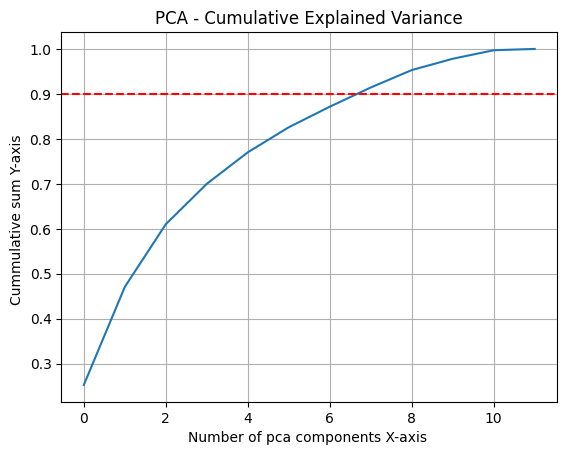

In [43]:
import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of pca components X-axis ")
plt.ylabel("Cummulative sum Y-axis ")
plt.title("PCA - Cumulative Explained Variance")
plt.axhline(y=0.90, color='r', linestyle='--')
plt.grid()
plt.show()

In [73]:
# means at 6 or 7  we get 90 % varience we can try these as principal component values

pca = PCA(n_components=7)
X_train_pca_b = pca.fit_transform(X_train_trf)
X_test_pca_b = pca.transform(X_test_trf)

In [74]:
knn = KNeighborsClassifier()

knn.fit(X_train_pca_b,y_train)

KNeighborsClassifier()

In [75]:
y_pred_pca = knn.predict(X_test_pca_b)

In [61]:
y_pred_pca

array(['red', 'red', 'white', ..., 'white', 'white', 'red'], dtype=object)

In [76]:
accuracy_score(y_test,y_pred_pca)

0.987724268177526

In [77]:
X_train_pca_b.shape

(4236, 7)